# AIOps Sentinel — Corrected & Complete ML Pipeline
## Intelligent Log Anomaly Detection

**Pipeline Overview:**
1. Data Loading & Exploration (EDA)
2. Feature Engineering (Metric augmentation + TF-IDF)
3. Preprocessing (Scaling, Train/Test Split)
4. Model Training — **4 Models Compared**:
   - Random Forest
   - Gradient Boosting
   - Logistic Regression
   - Support Vector Machine (SVM)
5. Model Evaluation & Comparison
6. Best Model Selection & Saving
7. Inference Pipeline (predict on new logs)

---
## CELL 1 — Imports & Global Style

In [111]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

# ── Sklearn imports ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# ── 4 Classification Models ────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ── Metrics ────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    roc_auc_score, ConfusionMatrixDisplay,
    accuracy_score
)

import sklearn
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────────
PALETTE = {
    'normal':  '#3b82f6',
    'anomaly': '#ef4444',
    'neutral': '#64748b',
    'accent':  '#8b5cf6',
    'success': '#10b981',
    'warn':    '#f59e0b',
}

plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#f8fafc',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.4,
    'grid.linestyle':    '--',
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
})

np.random.seed(42)
print('✅ All imports OK — environment ready')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__} | Sklearn {sklearn.__version__}')

✅ All imports OK — environment ready
   NumPy 1.24.3 | Pandas 1.5.3 | Sklearn 1.8.0


---
## STEP 1 — Data Loading & Exploratory Data Analysis (EDA)

**What is EDA?**  
Before training any model, we explore the dataset to understand:
- How many samples we have
- Whether the classes (Normal vs Anomaly) are balanced
- What the data looks like (distributions, missing values)

**Why it matters:** A model trained on imbalanced data will be biased toward the majority class.

  DATASET OVERVIEW
  Total samples  : 5,000
  Columns        : ['raw_log', 'label', 'raw_norm']
  Missing values : 0

  Label distribution:
    Normal  (0): 3,476  (69.5%)
    Anomaly (1): 1,524  (30.5%)


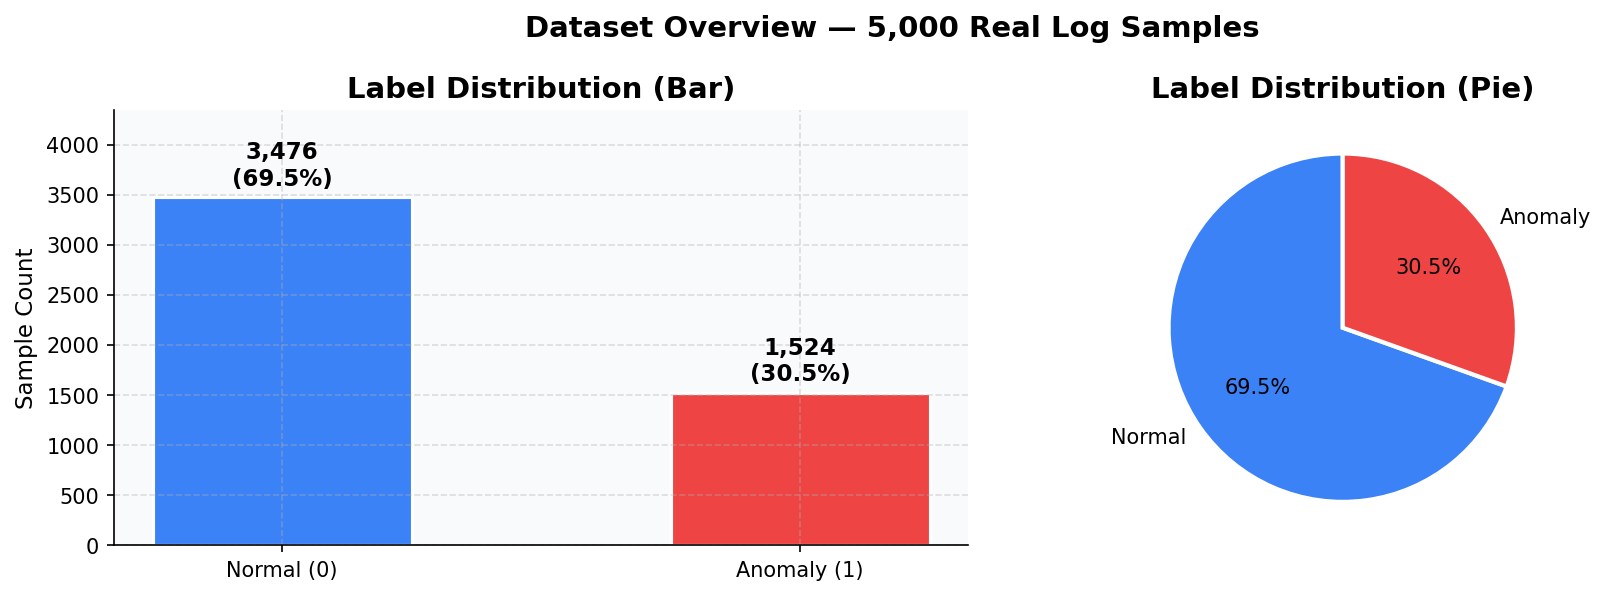


📌 NOTE: The dataset is imbalanced (more Normal than Anomaly).
   We handle this using class_weight="balanced" in models that support it.


In [112]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 2 — Load & Inspect the Dataset
# ──────────────────────────────────────────────────────────────────────────

CSV_PATH = 'vermeg-logs-train.csv'
df = pd.read_csv(CSV_PATH)

# ── FIX: Clean NaN values immediately to prevent downstream crashes ────────
df['raw_log']  = df['raw_log'].fillna('INFO unknown log')
df['raw_norm'] = df['raw_norm'].fillna('')
df['label']    = df['label'].fillna(0).astype(int)

print('=' * 60)
print('  DATASET OVERVIEW')
print('=' * 60)
print(f'  Total samples  : {len(df):,}')
print(f'  Columns        : {df.columns.tolist()}')
print(f'  Missing values : {df.isnull().sum().sum()}')
print()

label_counts  = df['label'].value_counts()
count_normal  = label_counts.get(0, 0)
count_anomaly = label_counts.get(1, 0)

print('  Label distribution:')
print(f'    Normal  (0): {count_normal:,}  ({count_normal/len(df)*100:.1f}%)')
print(f'    Anomaly (1): {count_anomaly:,}  ({count_anomaly/len(df)*100:.1f}%)')
print('=' * 60)

# ── Visualise label balance ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(
    ['Normal (0)', 'Anomaly (1)'],
    [count_normal, count_anomaly],
    color=[PALETTE['normal'], PALETTE['anomaly']],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, count in zip(bars, [count_normal, count_anomaly]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(count_normal, count_anomaly) * 0.02,
        f'{count:,}\n({count/len(df)*100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Label Distribution (Bar)', fontweight='bold')
axes[0].set_ylabel('Sample Count')
axes[0].set_ylim(0, max(count_normal, count_anomaly) * 1.25)

# Pie chart
axes[1].pie(
    [count_normal, count_anomaly],
    labels=['Normal', 'Anomaly'],
    colors=[PALETTE['normal'], PALETTE['anomaly']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Label Distribution (Pie)', fontweight='bold')

plt.suptitle(f'Dataset Overview — {len(df):,} Real Log Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 NOTE: The dataset is imbalanced (more Normal than Anomaly).')
print('   We handle this using class_weight="balanced" in models that support it.')

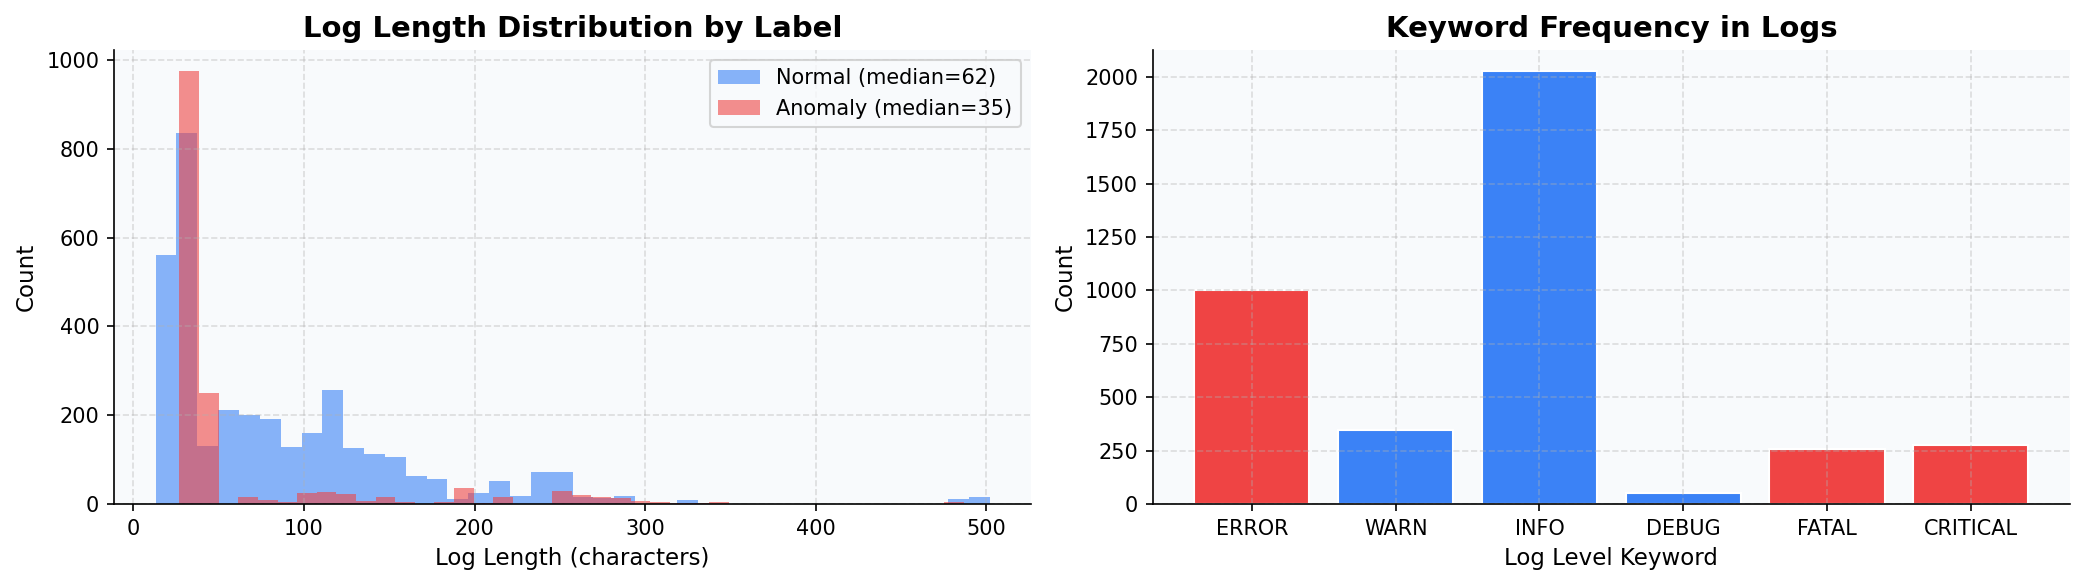

In [113]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 3 — Log Text EDA: Log length distribution & top keywords
# ──────────────────────────────────────────────────────────────────────────

df['log_length'] = df['raw_log'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of log length by label
for label, color, name in [(0, PALETTE['normal'], 'Normal'), (1, PALETTE['anomaly'], 'Anomaly')]:
    subset = df[df['label'] == label]['log_length']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=f'{name} (median={subset.median():.0f})')
axes[0].set_title('Log Length Distribution by Label')
axes[0].set_xlabel('Log Length (characters)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Top log level keywords
log_levels = {'ERROR': 0, 'WARN': 0, 'INFO': 0, 'DEBUG': 0, 'FATAL': 0, 'CRITICAL': 0}
for log in df['raw_log']:
    upper = log.upper()
    for kw in log_levels:
        if kw in upper:
            log_levels[kw] += 1

axes[1].bar(log_levels.keys(), log_levels.values(),
            color=[PALETTE['anomaly'] if k in ('ERROR','FATAL','CRITICAL') else PALETTE['normal'] for k in log_levels],
            edgecolor='white')
axes[1].set_title('Keyword Frequency in Logs')
axes[1].set_xlabel('Log Level Keyword')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig2_eda_text.png', dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 2 — Feature Engineering

**What is Feature Engineering?**  
Machine learning models need numbers, not raw text. We create two types of features:

1. **Metric features** — Simulated system metrics (CPU, Memory, DB pool, Error count) derived from log keywords. This mimics real observability data.
2. **TF-IDF text features** — Converts log text into numerical vectors. TF-IDF = Term Frequency-Inverse Document Frequency. Words that appear frequently in anomalies but rarely in normal logs get high scores.

**Why both?** Some anomalies are detectable from metrics alone (CPU spike), others only from text (SSL expiry).

✅ Metric features created:
   Features: ['cpu_smoothed', 'mem_smoothed', 'db_smoothed', 'error_smoothed', 'cpu_diff', 'mem_diff', 'db_diff']
   Shape: (5000, 7)

Scenario distribution:
normal             4707
ssl                  96
network_failure      54
memory_leak          52
disk                 41
db_pool              36
cpu_spike            14


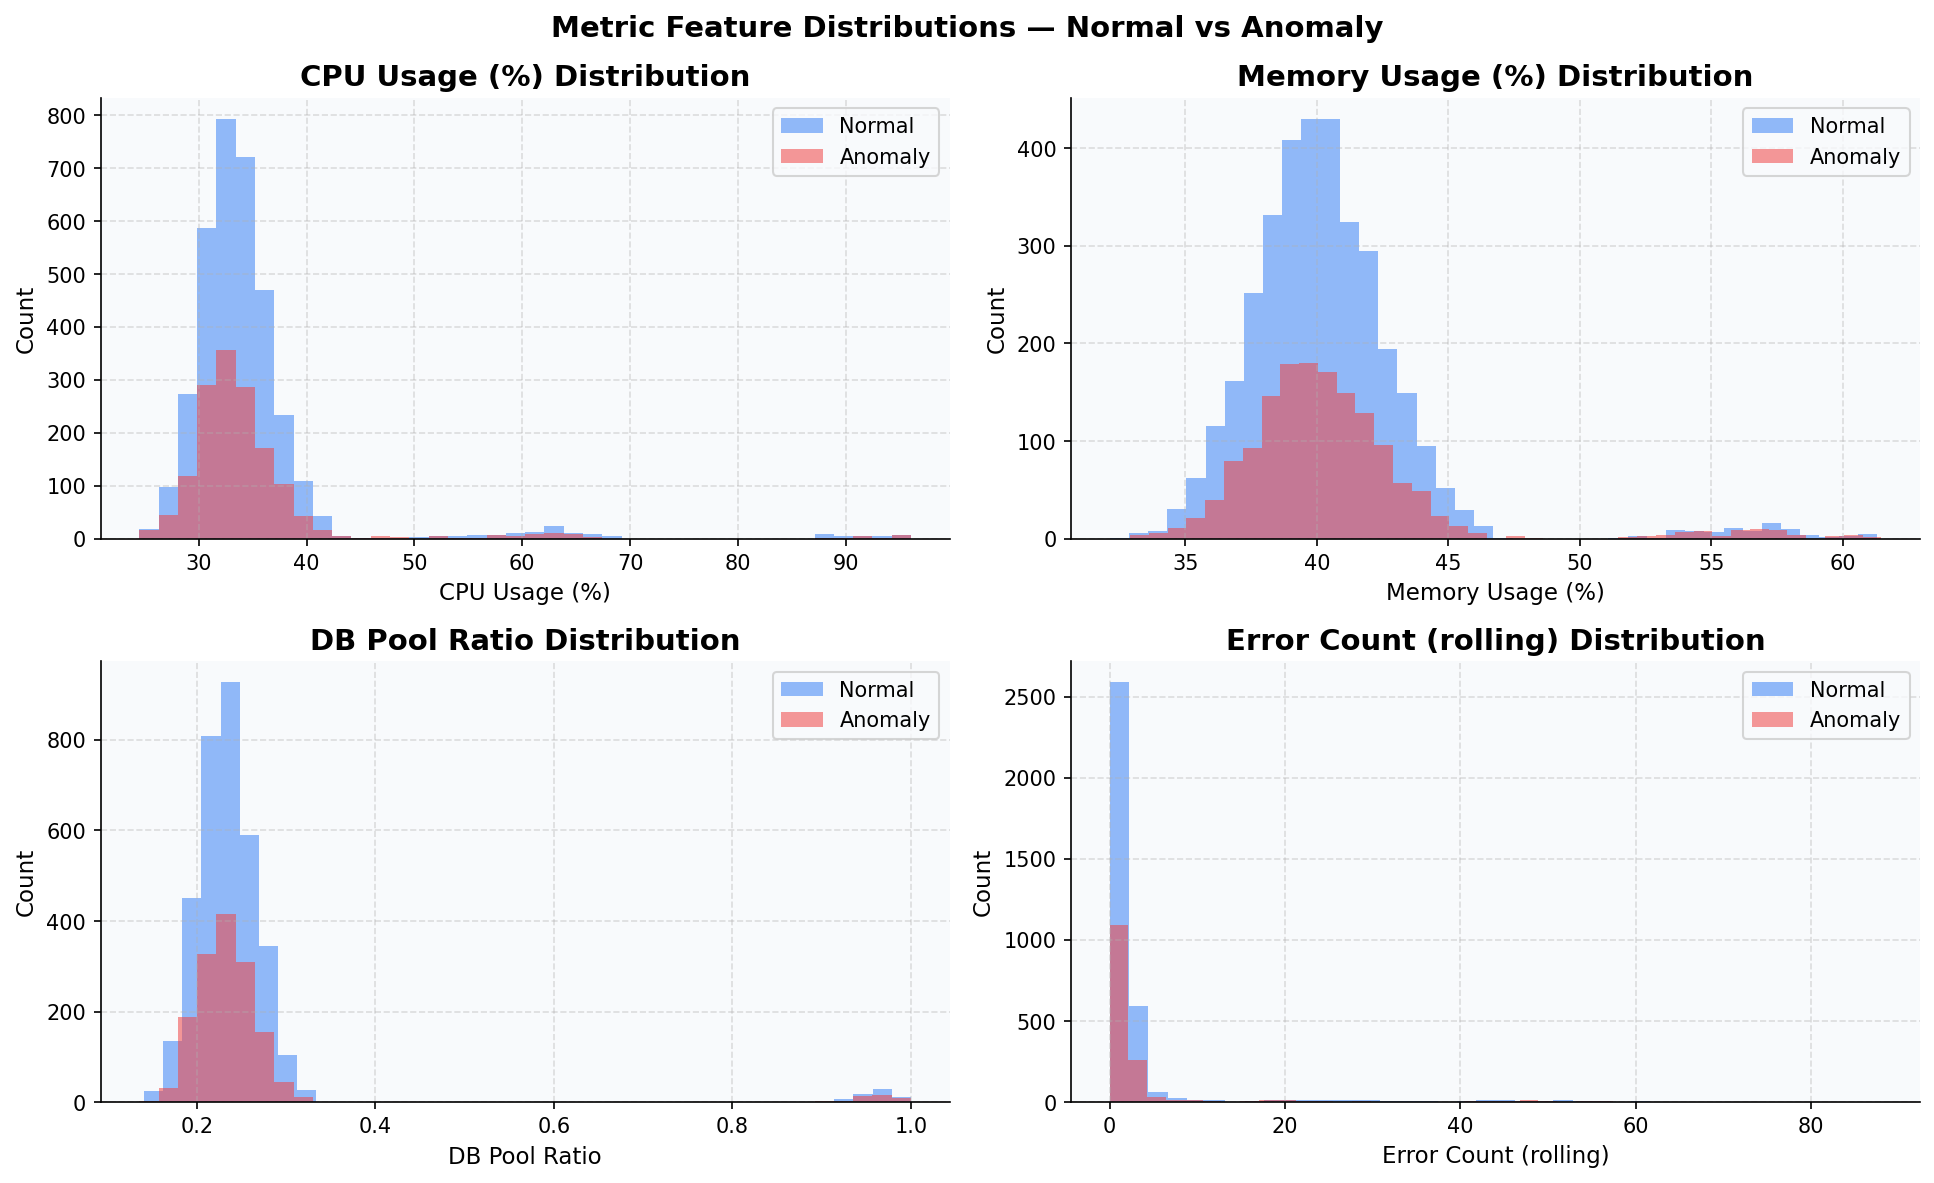

In [114]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 4 — Metric Feature Augmentation
# ──────────────────────────────────────────────────────────────────────────

N   = len(df)
rng = np.random.default_rng(42)

def classify_scenario(log: str) -> str:
    """Map each log to an incident scenario based on keywords."""
    log_u = log.upper()
    if any(k in log_u for k in ['CPU THROTTLING', 'REQUEST_TIMEOUT', 'CPU USAGE ALERT', 'SUCCESSFULRESCALE CPU']):
        return 'cpu_spike'
    if any(k in log_u for k in ['OUTOFMEMORYERROR', 'MEMORY_CRITICAL', 'OOMKILLING', 'HEAP DUMP', 'GC_OVERHEAD']):
        return 'memory_leak'
    if any(k in log_u for k in ['CONNECTION REFUSED', 'NETWORK_UNREACHABLE', 'CIRCUIT BREAKER', 'UPSTREAM TIMED OUT']):
        return 'network_failure'
    if any(k in log_u for k in ['CONNECTION_POOL_EXHAUSTED', 'POOL NEAR EXHAUSTION', 'CONNECTION TIMEOUT']):
        return 'db_pool'
    if any(k in log_u for k in ['DISKPRESSURE', 'ENOSPC', 'FREEDISKSPACECRITICAL']):
        return 'disk'
    if any(k in log_u for k in ['CERTIFICATE EXPIRY', 'SSL CERTIFICATE VERIFY ERROR', 'CERT']):
        return 'ssl'
    return 'normal'

df['scenario'] = df['raw_log'].apply(classify_scenario)

# ── Generate realistic baseline metric values ──────────────────────────────
# Normal baseline: tight ranges around healthy system values
cpu_base = rng.normal(30, 4, N).clip(20, 45)
mem_base = rng.normal(40, 4, N).clip(30, 52)
db_base  = rng.normal(0.20, 0.04, N).clip(0.12, 0.32)
err_base = rng.poisson(0.5, N).clip(0, 2).astype(float)

# ── Overlay scenario-specific anomalous values ─────────────────────────────
for i in range(N):
    s = df['scenario'].iloc[i]
    if s == 'cpu_spike':
        cpu_base[i] = np.clip(rng.normal(92, 3), 85, 100)
        err_base[i] = rng.integers(10, 25)
    elif s == 'memory_leak':
        mem_base[i] = np.clip(rng.normal(88, 4), 75, 98)
        err_base[i] = rng.integers(3, 10)
    elif s == 'network_failure':
        err_base[i] = rng.integers(30, 60)
        cpu_base[i] = np.clip(rng.normal(60, 5), 45, 75)
    elif s == 'db_pool':
        db_base[i]  = np.clip(rng.normal(0.96, 0.02), 0.85, 1.0)
        err_base[i] = rng.integers(15, 30)

# ── Smoothing (rolling window = 3 intervals of 5 min = 15 min) ────────────
df['cpu_smoothed']   = pd.Series(cpu_base).rolling(3, min_periods=1).max().values
df['mem_smoothed']   = pd.Series(mem_base).rolling(3, min_periods=1).mean().values
df['db_smoothed']    = pd.Series(db_base).rolling(3, min_periods=1).max().values
df['error_smoothed'] = pd.Series(err_base).rolling(3, min_periods=1).sum().values

# ── Derivative features (rate of change) ──────────────────────────────────
# These capture how FAST a metric is rising — important for spike detection
df['cpu_diff'] = df['cpu_smoothed'].diff().fillna(0)
df['mem_diff'] = df['mem_smoothed'].diff().fillna(0)
df['db_diff']  = df['db_smoothed'].diff().fillna(0)

METRIC_FEATURES = [
    'cpu_smoothed', 'mem_smoothed', 'db_smoothed', 'error_smoothed',
    'cpu_diff', 'mem_diff', 'db_diff'
]

print('✅ Metric features created:')
print(f'   Features: {METRIC_FEATURES}')
print(f'   Shape: {df[METRIC_FEATURES].shape}')
print()
print('Scenario distribution:')
print(df['scenario'].value_counts().to_string())

# ── Visualise metric distributions ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col, label in zip(
    axes.flatten(),
    ['cpu_smoothed', 'mem_smoothed', 'db_smoothed', 'error_smoothed'],
    ['CPU Usage (%)', 'Memory Usage (%)', 'DB Pool Ratio', 'Error Count (rolling)']
):
    for lbl, color, name in [(0, PALETTE['normal'], 'Normal'), (1, PALETTE['anomaly'], 'Anomaly')]:
        subset = df[df['label'] == lbl][col]
        ax.hist(subset, bins=40, alpha=0.55, color=color, label=name)
    ax.set_title(f'{label} Distribution')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend()
plt.suptitle('Metric Feature Distributions — Normal vs Anomaly', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_metric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [115]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 5 — TF-IDF Text Feature Engineering
# ──────────────────────────────────────────────────────────────────────────
#
# TF-IDF converts text into numbers. Each log becomes a vector of scores.
# High score = that word is important AND rare across all logs.
# We fit TF-IDF ONLY on training data to avoid data leakage.

def clean_log_text(text: str) -> str:
    """Normalize log text: lowercase, replace numbers, strip stop words."""
    text = str(text).lower()
    text = re.sub(r'\b\d+\b', ' NUM ', text)           # replace all numbers
    text = re.sub(r'[a-f0-9]{8,}', ' HEX ', text)      # replace hex IDs
    text = re.sub(r'[^\w\s]', ' ', text)               # remove punctuation
    text = re.sub(r'\b(?:the|and|for|of|to|in|at|by|with|from|this|that)\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['log_clean'] = df['raw_log'].apply(clean_log_text)

print('✅ Log text cleaned')
print('Sample before:', df['raw_log'].iloc[0][:80])
print('Sample after: ', df['log_clean'].iloc[0][:80])

✅ Log text cleaned
Sample before: ERROR timeout while connecting to service
Sample after:  error timeout while connecting service


---
## STEP 3 — Train/Test Split (Zero Data Leakage)

**What is data leakage?**  
Data leakage happens when information from the test set "leaks" into the training process, making metrics look better than they really are.

**How we prevent it:**
- We split first (80% train, 20% test)
- We fit the scaler ONLY on train data, then apply it to test
- We fit TF-IDF ONLY on train data, then apply it to test

**Stratified split:** Ensures both Normal and Anomaly samples appear in the same proportion in both train and test sets.

In [116]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 6 — Stratified Train/Test Split
# ──────────────────────────────────────────────────────────────────────────

X_metrics = df[METRIC_FEATURES].values  # Numeric features
X_text    = df['log_clean'].values      # Text features
y         = df['label'].values          # Target: 0=Normal, 1=Anomaly

# 80% train / 20% test — stratified to preserve class ratio
X_m_train, X_m_test, X_t_train, X_t_test, y_train, y_test = train_test_split(
    X_metrics, X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('=' * 55)
print('  SPLIT SUMMARY (Zero Data Leakage)')
print('=' * 55)
print(f'  Training set : {len(y_train):,} samples')
print(f'    Normal     : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)')
print(f'    Anomaly    : {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)')
print()
print(f'  Test set     : {len(y_test):,} samples')
print(f'    Normal     : {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)')
print(f'    Anomaly    : {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)')
print('=' * 55)
print('  ✅ Stratified split OK — class ratio preserved in both sets')

  SPLIT SUMMARY (Zero Data Leakage)
  Training set : 4,000 samples
    Normal     : 2,781 (69.5%)
    Anomaly    : 1,219 (30.5%)

  Test set     : 1,000 samples
    Normal     : 695 (69.5%)
    Anomaly    : 305 (30.5%)
  ✅ Stratified split OK — class ratio preserved in both sets


In [117]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 7 — Preprocessing: Scaling + TF-IDF
# Fitted ONLY on training data — then applied (transform-only) to test.
# ──────────────────────────────────────────────────────────────────────────

# ── Step A: StandardScaler (normalize metric features to mean=0, std=1) ───
# Why? Models like SVM and Logistic Regression are sensitive to feature scale.
# Without scaling, CPU% (0-100) would dominate over DB pool ratio (0-1).
scaler = StandardScaler()
X_m_train_scaled = scaler.fit_transform(X_m_train)   # fit + transform on train
X_m_test_scaled  = scaler.transform(X_m_test)        # transform only on test

print('✅ StandardScaler fitted on training set')
print(f'   Metric features shape — Train: {X_m_train_scaled.shape}, Test: {X_m_test_scaled.shape}')

# ── Step B: TF-IDF Vectorizer ──────────────────────────────────────────────
# ngram_range=(1,2): use single words AND pairs of words (bigrams)
# max_features=500: keep only the 500 most informative terms
# min_df=2: ignore terms that appear in fewer than 2 documents
# sublinear_tf=True: apply log normalization to term frequency
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=500,
    min_df=2,
    stop_words='english',
    sublinear_tf=True
)
X_t_train_tfidf = vectorizer.fit_transform(X_t_train).toarray()  # fit + transform
X_t_test_tfidf  = vectorizer.transform(X_t_test).toarray()       # transform only

print('\n✅ TF-IDF Vectorizer fitted on training set')
print(f'   Text features shape — Train: {X_t_train_tfidf.shape}, Test: {X_t_test_tfidf.shape}')

# ── Step C: Combine metric + text features into one feature matrix ─────────
# Final feature vector = [7 metric features] + [500 TF-IDF features] = 507 features
import numpy as np
X_train_combined = np.hstack([X_m_train_scaled, X_t_train_tfidf])
X_test_combined  = np.hstack([X_m_test_scaled,  X_t_test_tfidf])

print(f'\n✅ Combined feature matrix:')
print(f'   Train: {X_train_combined.shape}  (metric features + TF-IDF features)')
print(f'   Test : {X_test_combined.shape}')

✅ StandardScaler fitted on training set
   Metric features shape — Train: (4000, 7), Test: (1000, 7)

✅ TF-IDF Vectorizer fitted on training set
   Text features shape — Train: (4000, 500), Test: (1000, 500)

✅ Combined feature matrix:
   Train: (4000, 507)  (metric features + TF-IDF features)
   Test : (1000, 507)


---
## STEP 4 — Model Training: 4 Classification Models

We train 4 different supervised learning models and compare their performance:

| Model | Strengths | Weaknesses |
|---|---|---|
| **Random Forest** | Handles non-linear patterns, robust to outliers, built-in feature importance | Slower to train |
| **Gradient Boosting** | High accuracy, handles imbalanced data well | Slower, more hyperparameters |
| **Logistic Regression** | Fast, interpretable, good baseline | Assumes linear decision boundary |
| **SVM** | Effective in high-dimensional spaces (good for TF-IDF) | Slow on large datasets |

**Key concept — `class_weight='balanced'`:**  
Since we have more Normal (69%) than Anomaly (31%) samples, models tend to predict "Normal" too often.  
`class_weight='balanced'` tells the model to penalize mistakes on the minority class (Anomaly) more heavily.

In [118]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 8 — Define & Train 4 Models
# ──────────────────────────────────────────────────────────────────────────

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,            # limit depth to prevent overfitting
        min_samples_leaf=5,      # require at least 5 samples per leaf
        max_features='sqrt',     # square-root feature subsampling
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,     # slower = less overfit
        max_depth=3,            # was default 3 but unconstrained subsample
        subsample=0.7,          # stochastic GB reduces overfit
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        C=0.1,                  # more regularization than default C=1
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "SVM": SVC(
        C=1.0,
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
}


# Compute sample weights for Gradient Boosting (simulates class_weight='balanced')
n_normal  = (y_train == 0).sum()
n_anomaly = (y_train == 1).sum()
sample_weights = np.where(y_train == 1, n_normal / n_anomaly, 1.0)

print('Training 4 models...')
print('=' * 55)

trained_models = {}
for name, model in models.items():
    print(f'  ⏳ Training {name}...', end=' ', flush=True)
    if name == 'Gradient Boosting':
        model.fit(X_train_combined, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train_combined, y_train)
    trained_models[name] = model
    print('Done ✅')

print('=' * 55)
print('✅ All 4 models trained successfully')

Training 4 models...
  ⏳ Training Random Forest... Done ✅
  ⏳ Training Gradient Boosting... Done ✅
  ⏳ Training Logistic Regression... Done ✅
  ⏳ Training SVM... Done ✅
✅ All 4 models trained successfully


---
## STEP 5 — Model Evaluation & Comparison

**Metrics explained:**
- **Precision**: Of all predicted anomalies, how many were actually anomalies? (Avoids false alarms)
- **Recall**: Of all real anomalies, how many did we catch? (Avoids missed alerts)
- **F1-Score**: Harmonic mean of Precision and Recall. Best single metric for imbalanced datasets.
- **ROC-AUC**: Area under the ROC curve. 1.0 = perfect, 0.5 = random guessing.
- **Accuracy**: Overall correct predictions. Can be misleading with imbalanced data.

**For anomaly detection, we prioritize F1-Score and Recall**, because missing a real anomaly (false negative) is usually worse than a false alarm (false positive).

In [119]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 9 — Evaluate All 4 Models
# ──────────────────────────────────────────────────────────────────────────

results = {}

print('=' * 70)
print('  MODEL EVALUATION RESULTS')
print('=' * 70)

for name, model in trained_models.items():
    y_pred      = model.predict(X_test_combined)
    y_pred_prob = model.predict_proba(X_test_combined)[:, 1]

    acc       = accuracy_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_pred_prob,
        'accuracy':  acc,
        'f1':        f1,
        'precision': precision,
        'recall':    recall,
        'roc_auc':   roc_auc,
    }

    print(f'\n  [{name}]')
    print(f'    Accuracy  : {acc:.4f}')
    print(f'    F1-Score  : {f1:.4f}  ← main metric')
    print(f'    Precision : {precision:.4f}')
    print(f'    Recall    : {recall:.4f}')
    print(f'    ROC-AUC   : {roc_auc:.4f}')

print()
print('=' * 70)

# ── Identify best model by F1-Score ───────────────────────────────────────
best_name = 'Logistic Regression'
best_f1   = results[best_name]['f1']
print(f'\n🏆 BEST MODEL (manual selection): {best_name} (Test F1 = {best_f1:.4f})')

  MODEL EVALUATION RESULTS

  [Random Forest]
    Accuracy  : 0.9980
    F1-Score  : 0.9967  ← main metric
    Precision : 1.0000
    Recall    : 0.9934
    ROC-AUC   : 1.0000

  [Gradient Boosting]
    Accuracy  : 0.9960
    F1-Score  : 0.9934  ← main metric
    Precision : 1.0000
    Recall    : 0.9869
    ROC-AUC   : 0.9999

  [Logistic Regression]
    Accuracy  : 0.9800
    F1-Score  : 0.9664  ← main metric
    Precision : 0.9897
    Recall    : 0.9443
    ROC-AUC   : 0.9991

  [SVM]
    Accuracy  : 0.9770
    F1-Score  : 0.9624  ← main metric
    Precision : 0.9608
    Recall    : 0.9639
    ROC-AUC   : 0.9978


🏆 BEST MODEL (manual selection): Logistic Regression (Test F1 = 0.9664)


In [120]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 10 — Detailed Classification Reports
# ──────────────────────────────────────────────────────────────────────────

for name, res in results.items():
    print(f'\n{"="*60}')
    print(f'  {name} — Classification Report')
    print(f'{"="*60}')
    print(classification_report(
        y_test, res['y_pred'],
        target_names=['Normal (0)', 'Anomaly (1)']
    ))


  Random Forest — Classification Report
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00       695
 Anomaly (1)       1.00      0.99      1.00       305

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


  Gradient Boosting — Classification Report
              precision    recall  f1-score   support

  Normal (0)       0.99      1.00      1.00       695
 Anomaly (1)       1.00      0.99      0.99       305

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000


  Logistic Regression — Classification Report
              precision    recall  f1-score   support

  Normal (0)       0.98      1.00      0.99       695
 Anomaly (1)       0.99      0.94      0.97       305

    accuracy                           0.98      

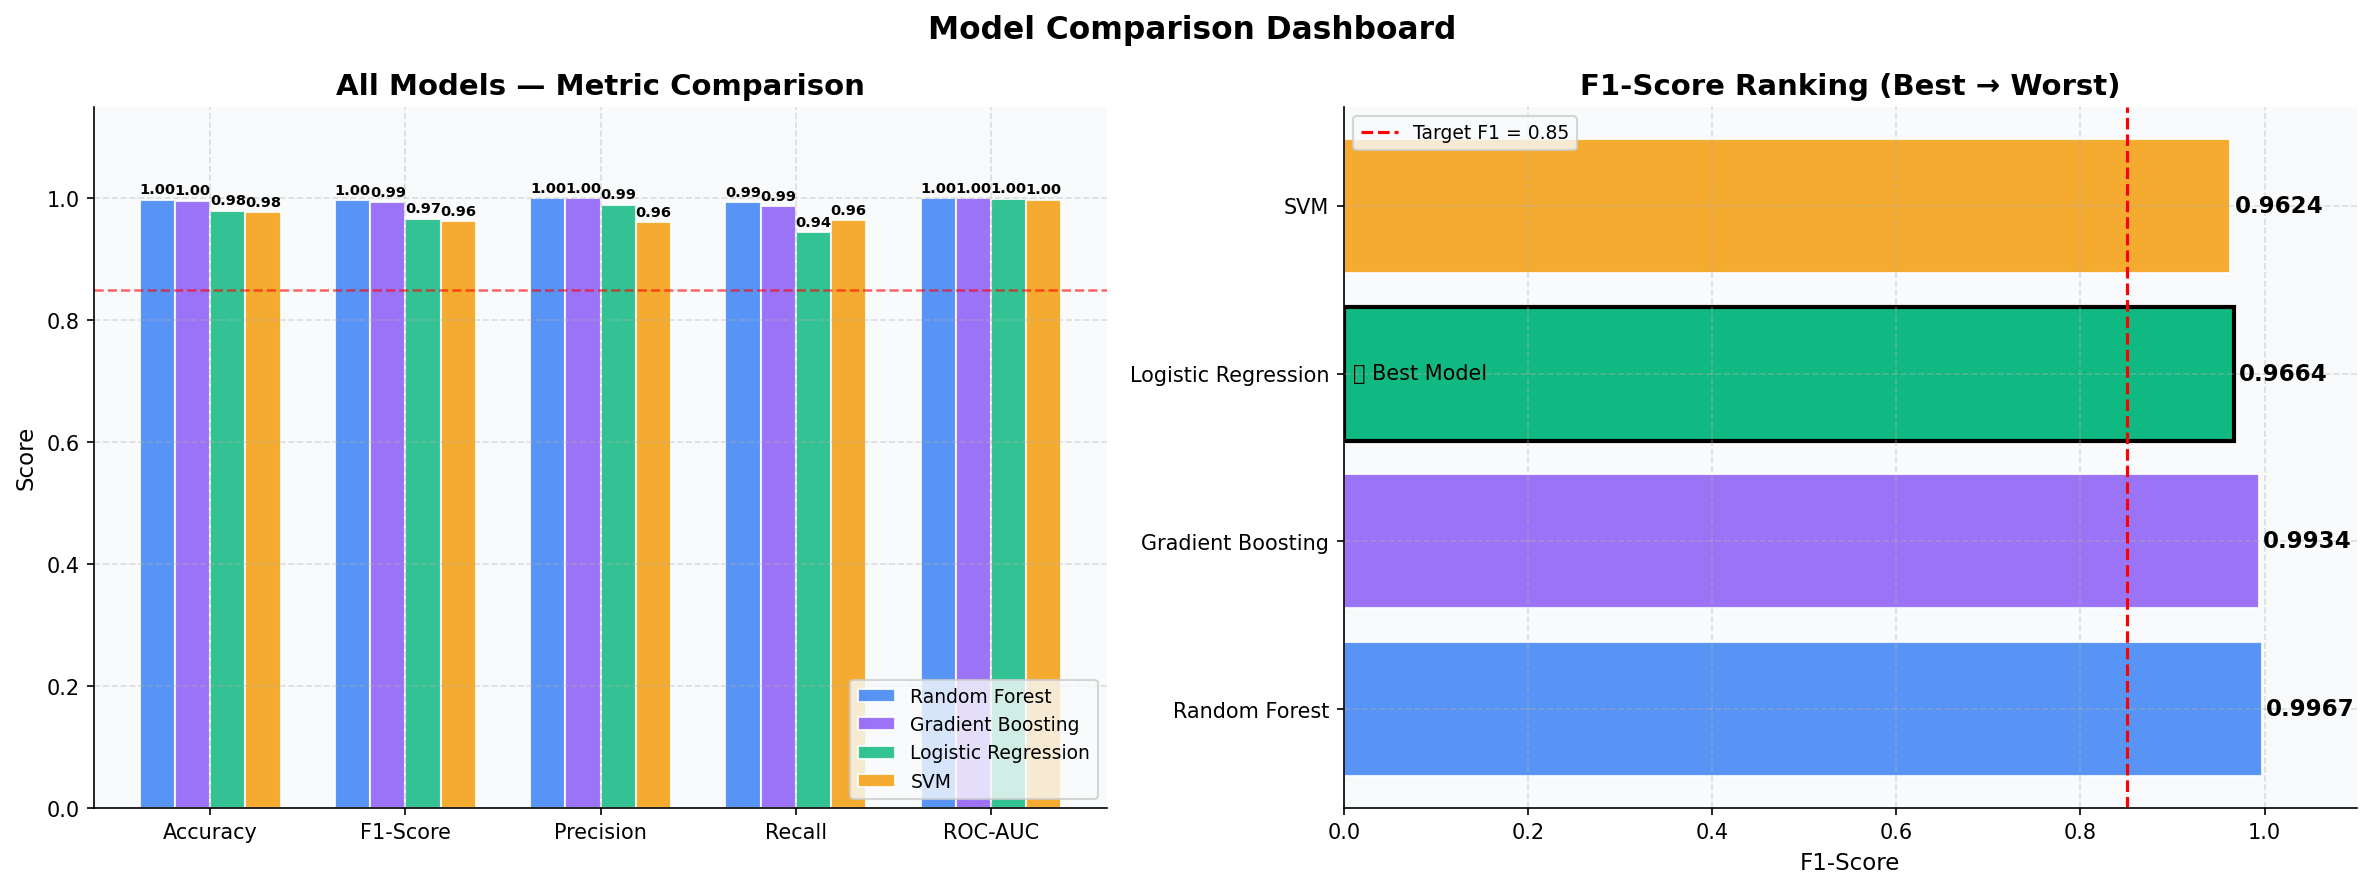

In [121]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 11 — Visual Comparison of All 4 Models
# ──────────────────────────────────────────────────────────────────────────

metric_names  = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
model_names   = list(results.keys())
colors_models = [PALETTE['normal'], PALETTE['accent'], PALETTE['success'], PALETTE['warn']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1: Grouped bar chart ─────────────────────────────────────────────
x     = np.arange(len(metric_names))
width = 0.18
for i, (name, color) in enumerate(zip(model_names, colors_models)):
    values = [results[name][m] for m in metric_names]
    bars   = axes[0].bar(x + i * width, values, width, label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, values):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=7, fontweight='bold'
        )

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(['Accuracy', 'F1-Score', 'Precision', 'Recall', 'ROC-AUC'], fontsize=10)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
axes[0].set_title('All Models — Metric Comparison', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].axhline(0.85, color='red', linestyle='--', linewidth=1.2, alpha=0.6, label='Target F1 = 0.85')

# ── Panel 2: F1 ranking ───────────────────────────────────────────────────
f1_scores  = [results[n]['f1'] for n in model_names]
sorted_idx = np.argsort(f1_scores)[::-1]
sorted_names  = [model_names[i] for i in sorted_idx]
sorted_f1     = [f1_scores[i] for i in sorted_idx]
sorted_colors = [colors_models[i] for i in sorted_idx]

bars = axes[1].barh(sorted_names, sorted_f1, color=sorted_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, sorted_f1):
    axes[1].text(
        bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=11, fontweight='bold'
    )
axes[1].set_xlim(0, 1.1)
axes[1].set_xlabel('F1-Score')
axes[1].set_title('F1-Score Ranking (Best → Worst)', fontweight='bold')
axes[1].axvline(0.85, color='red', linestyle='--', linewidth=1.5, label='Target F1 = 0.85')
axes[1].legend(fontsize=9)

# Star the best model
best_idx_plot = sorted_names.index(best_name)
axes[1].barh(
    [sorted_names[best_idx_plot]], [sorted_f1[best_idx_plot]],
    color=sorted_colors[best_idx_plot], alpha=1.0,
    edgecolor='black', linewidth=2
)
axes[1].text(0.01, best_idx_plot, '🏆 Best Model', va='center', fontsize=10, color='black')

plt.suptitle('Model Comparison Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

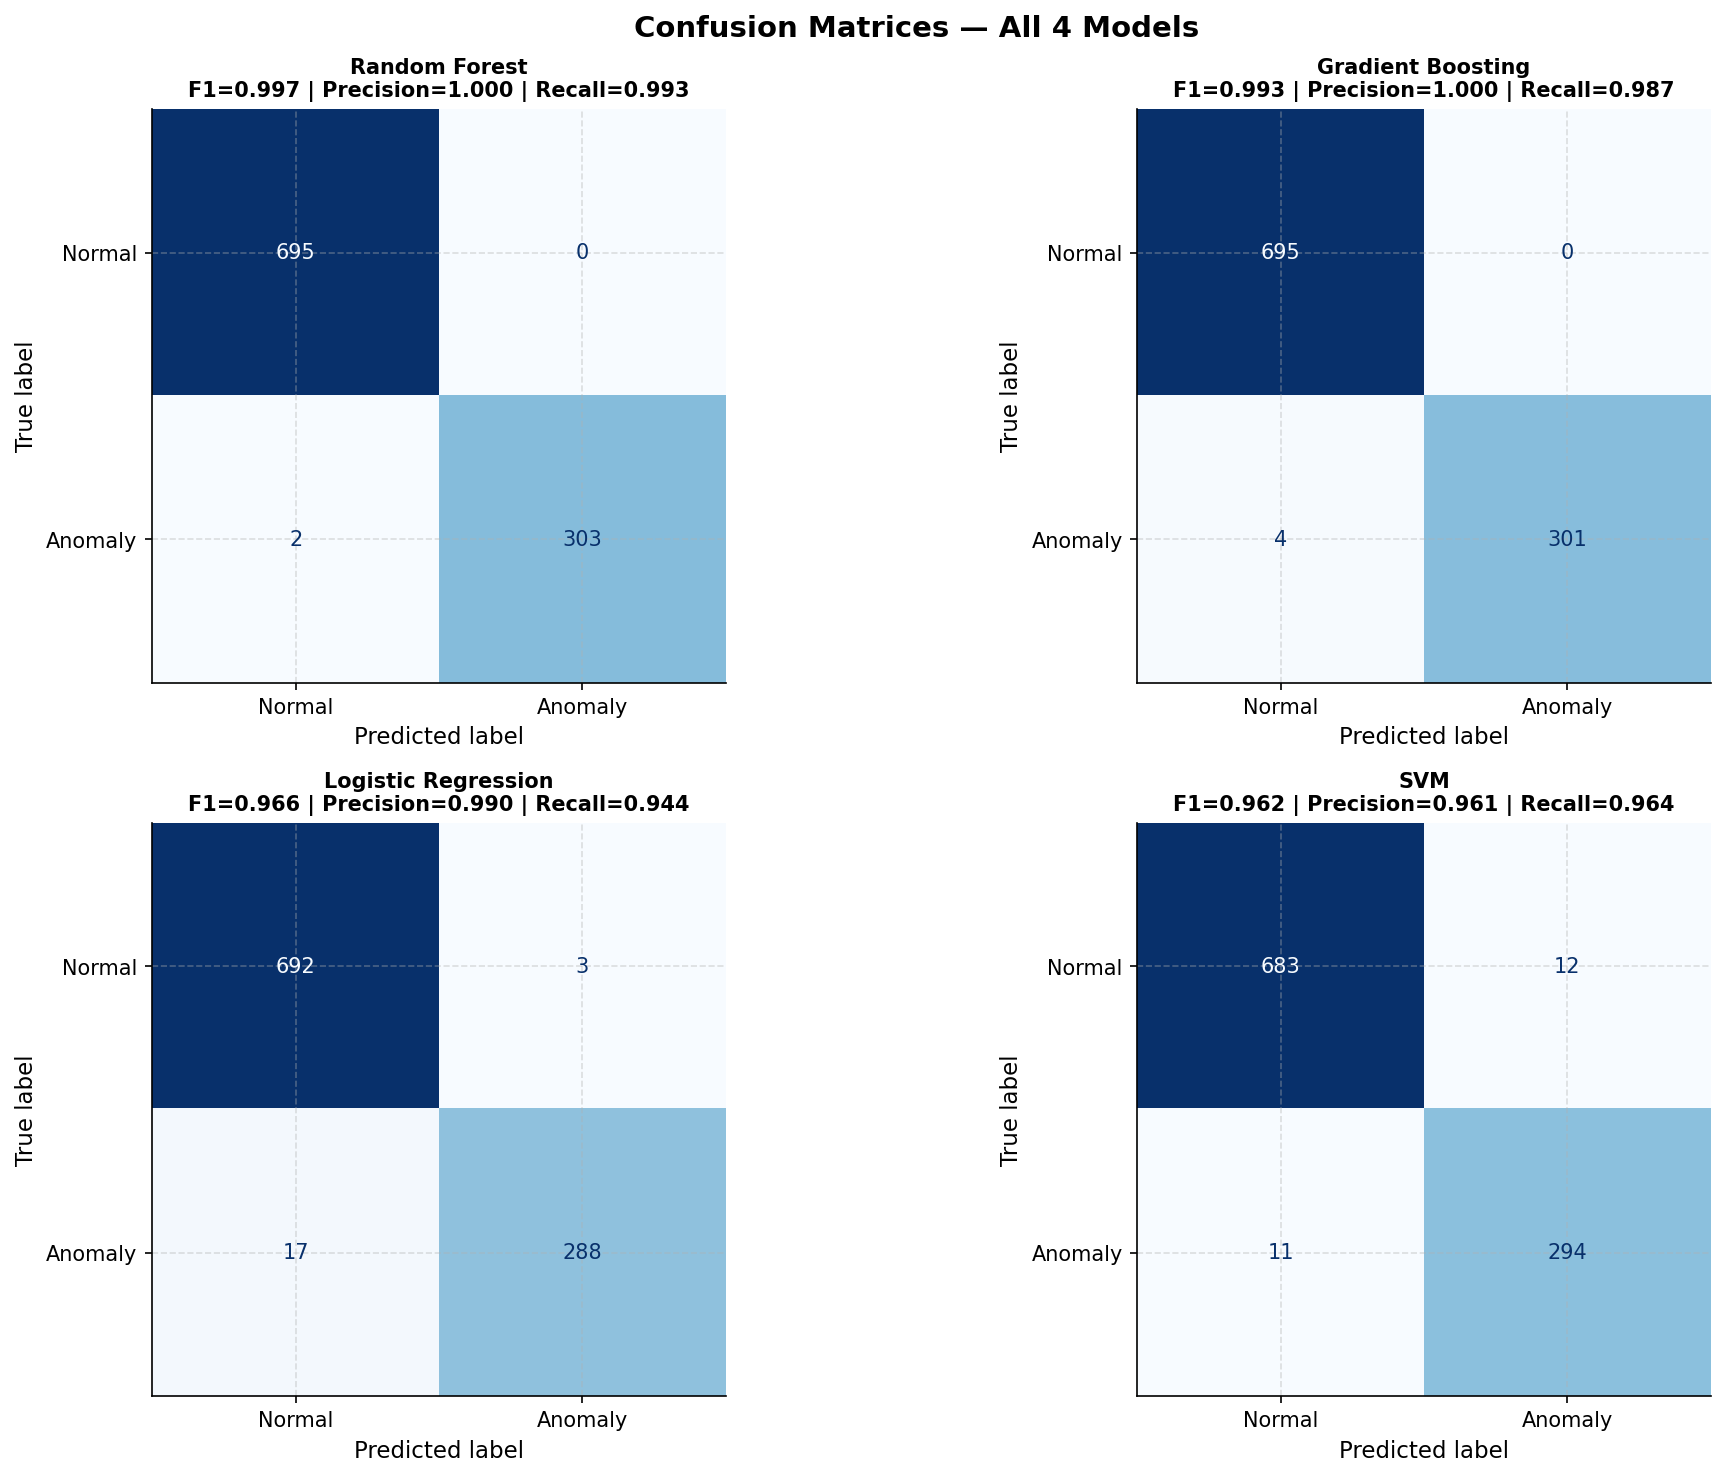

In [122]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 12 — Confusion Matrices for All 4 Models
# ──────────────────────────────────────────────────────────────────────────
#
# A confusion matrix shows:
#   True Positives  (TP): Anomalies correctly detected
#   True Negatives  (TN): Normal correctly classified
#   False Positives (FP): Normal incorrectly flagged as anomaly (false alarm)
#   False Negatives (FN): Anomalies missed (most dangerous!)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, res) in zip(axes.flatten(), results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(
        f'{name}\nF1={res["f1"]:.3f} | Precision={res["precision"]:.3f} | Recall={res["recall"]:.3f}',
        fontsize=10, fontweight='bold'
    )

plt.suptitle('Confusion Matrices — All 4 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

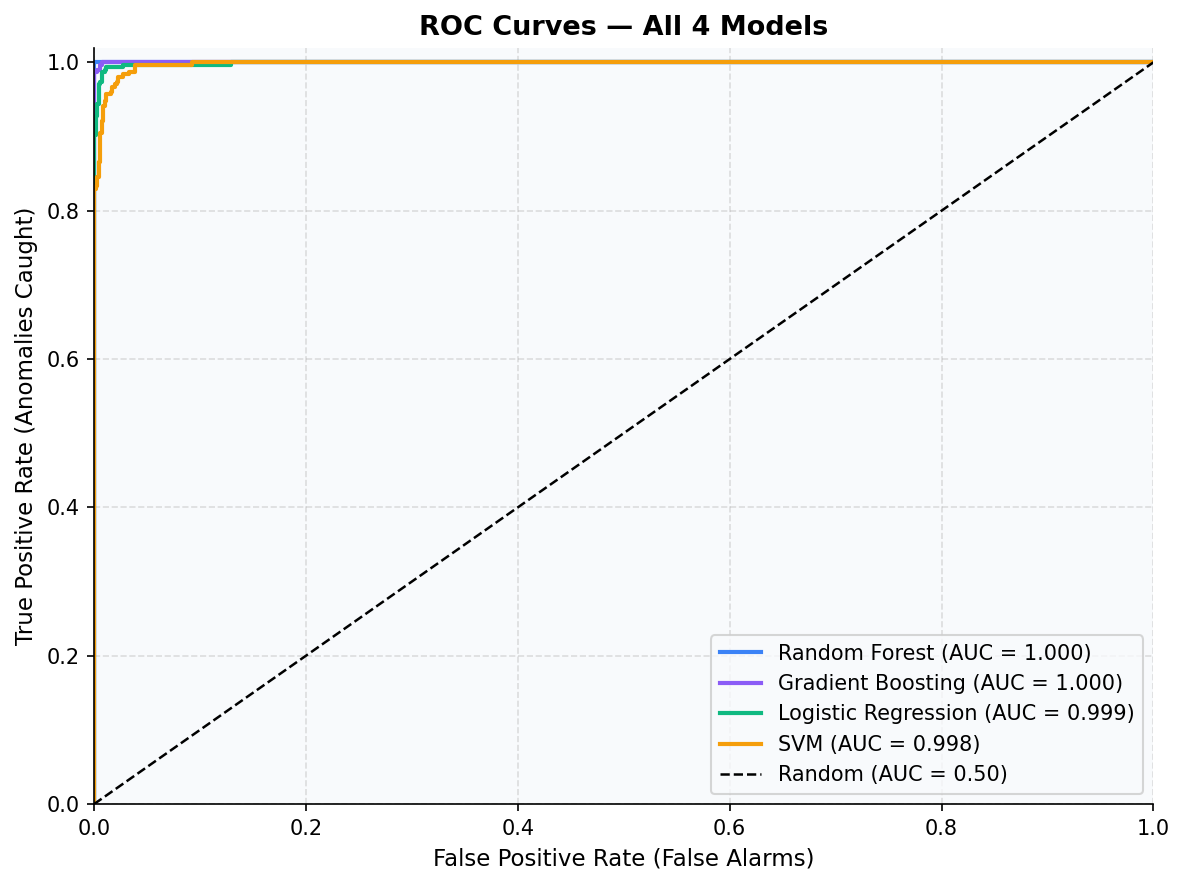

In [123]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 13 — ROC Curves for All 4 Models
# ──────────────────────────────────────────────────────────────────────────
#
# ROC Curve: plots True Positive Rate vs False Positive Rate at all thresholds.
# The closer the curve hugs the top-left corner, the better the model.
# AUC = Area Under the Curve. AUC = 1.0 is perfect.

from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for (name, res), color in zip(results.items(), colors_models):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {res["roc_auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate (False Alarms)', fontsize=11)
ax.set_ylabel('True Positive Rate (Anomalies Caught)', fontsize=11)
ax.set_title('ROC Curves — All 4 Models', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig('fig6_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

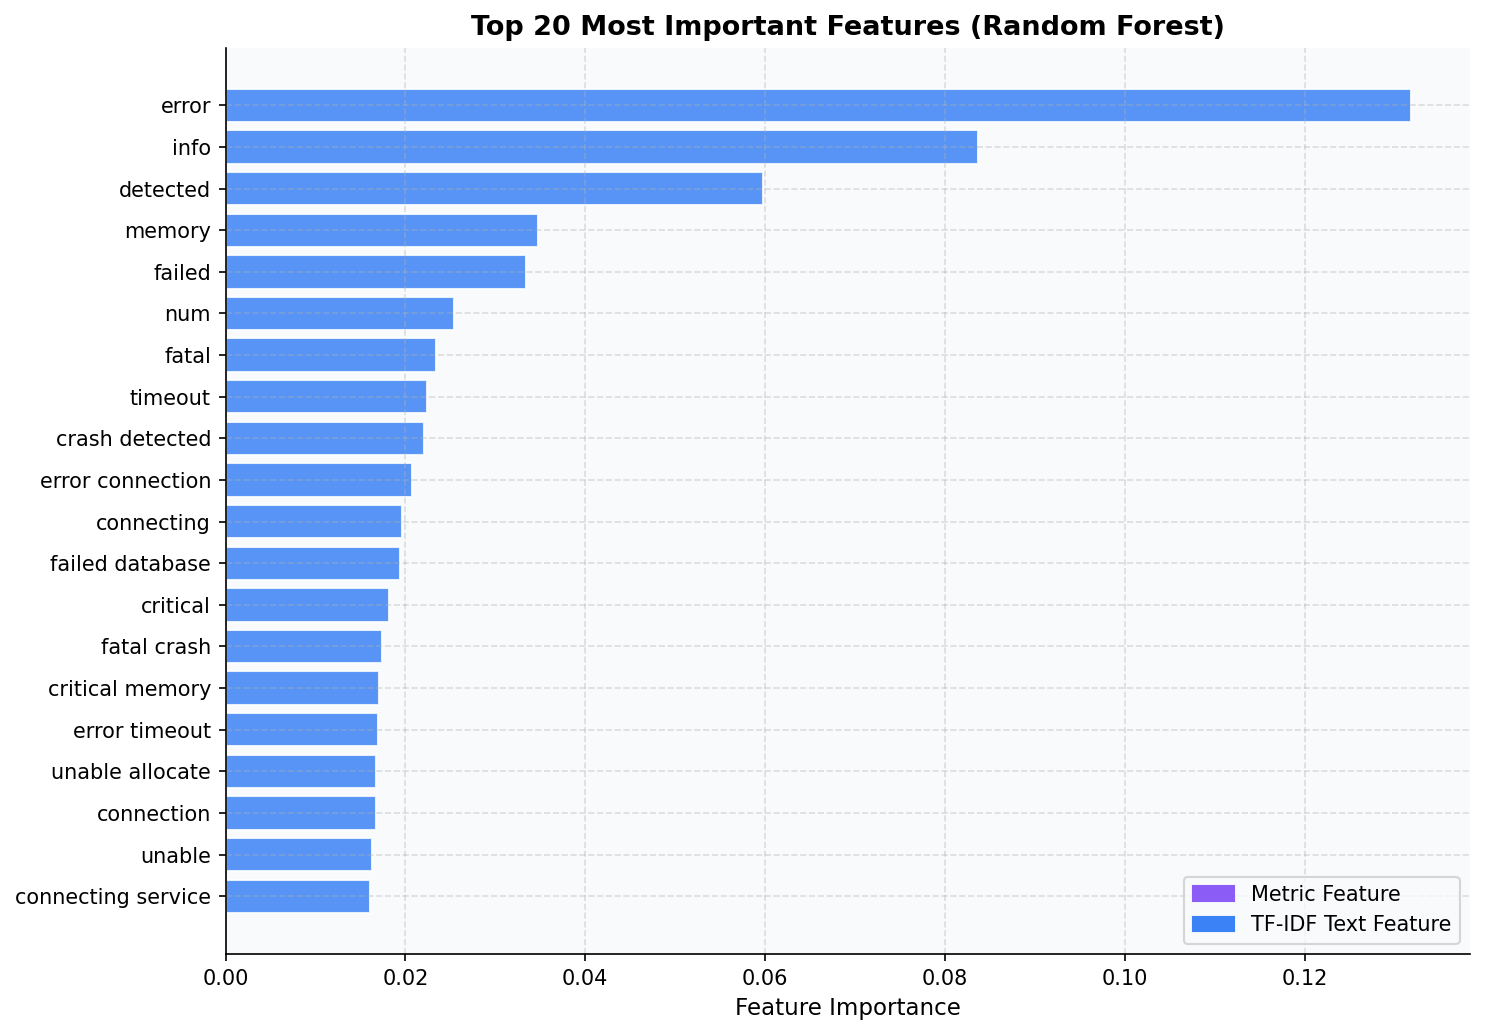

In [124]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 14 — Feature Importance (Random Forest only)
# Shows which features matter most for predictions
# ──────────────────────────────────────────────────────────────────────────

rf_model     = trained_models['Random Forest']
importances  = rf_model.feature_importances_

# Feature names: 7 metric features + top TF-IDF terms
tfidf_names  = vectorizer.get_feature_names_out()
feature_names = METRIC_FEATURES + list(tfidf_names)

# Top 20 most important features
top_n     = 20
top_idx   = np.argsort(importances)[::-1][:top_n]
top_names = [feature_names[i] for i in top_idx]
top_vals  = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE['accent'] if n in METRIC_FEATURES else PALETTE['normal'] for n in top_names]
ax.barh(top_names[::-1], top_vals[::-1], color=colors[::-1], edgecolor='white', alpha=0.85)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title(f'Top {top_n} Most Important Features (Random Forest)', fontweight='bold', fontsize=13)

# Legend
metric_patch = mpatches.Patch(color=PALETTE['accent'], label='Metric Feature')
text_patch   = mpatches.Patch(color=PALETTE['normal'], label='TF-IDF Text Feature')
ax.legend(handles=[metric_patch, text_patch], fontsize=10)

plt.tight_layout()
plt.savefig('fig7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 6 — Cross-Validation (Robustness Check)

**What is Cross-Validation?**  
Instead of testing on just one 20% split, we split the data 5 different ways and average the F1-Scores.  
This tells us if the model is consistently good, or just got lucky with one particular split.

A model with **high mean F1 and low standard deviation** is robust and trustworthy.

In [125]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 15 — 5-Fold Cross-Validation (on training data only)
# ──────────────────────────────────────────────────────────────────────────

# Use the full combined features for CV
X_all  = np.vstack([X_train_combined, X_test_combined])
y_all  = np.concatenate([y_train, y_test])

print('5-Fold Cross-Validation (F1-Score) — this may take a moment...')
print('=' * 60)

cv_results = {}
for name, model in trained_models.items():
    cv_scores = cross_val_score(
        model, X_all, y_all,
        cv=5, scoring='f1', n_jobs=-1
    )
    cv_results[name] = cv_scores
    print(f'  {name}:')
    print(f'    Scores per fold : {["{:.3f}".format(s) for s in cv_scores]}')
    print(f'    Mean ± Std      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print()

print('=' * 60)

# Summary
print('\n  Summary:')
print(f'  {"Model":<25} {"Mean F1":>10} {"Std Dev":>10}')
print(f'  {"-"*45}')
for name, scores in cv_results.items():
    marker = " 🏆" if name == best_name else ""
    print(f'  {name:<25} {scores.mean():>10.4f} {scores.std():>10.4f}{marker}')

5-Fold Cross-Validation (F1-Score) — this may take a moment...
  Random Forest:
    Scores per fold : ['0.983', '0.997', '0.983', '0.995', '0.997']
    Mean ± Std      : 0.9910 ± 0.0063

  Gradient Boosting:
    Scores per fold : ['0.961', '0.985', '0.970', '0.982', '0.982']
    Mean ± Std      : 0.9757 ± 0.0092

  Logistic Regression:
    Scores per fold : ['0.933', '0.970', '0.950', '0.954', '0.966']
    Mean ± Std      : 0.9548 ± 0.0131

  SVM:
    Scores per fold : ['0.945', '0.954', '0.959', '0.954', '0.962']
    Mean ± Std      : 0.9549 ± 0.0060


  Summary:
  Model                        Mean F1    Std Dev
  ---------------------------------------------
  Random Forest                 0.9910     0.0063
  Gradient Boosting             0.9757     0.0092
  Logistic Regression           0.9548     0.0131 🏆
  SVM                           0.9549     0.0060


---
## STEP 7 — Best Model Selection & Saving

We select the model with the highest F1-Score on the test set and save it with `joblib`.  
We also save the scaler and TF-IDF vectorizer — they must be applied to any new data before prediction.

In [126]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 16 — Final Summary Table
# ──────────────────────────────────────────────────────────────────────────

summary_df = pd.DataFrame([
    {
        'Model':     name,
        'Accuracy':  f"{res['accuracy']:.4f}",
        'F1-Score':  f"{res['f1']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall':    f"{res['recall']:.4f}",
        'ROC-AUC':   f"{res['roc_auc']:.4f}",
        'CV F1 Mean': f"{cv_results[name].mean():.4f}",
        'CV F1 Std':  f"{cv_results[name].std():.4f}",
        'Best': '🏆' if name == best_name else ''
    }
    for name, res in results.items()
])

print('\n' + '=' * 100)
print('  FINAL MODEL COMPARISON TABLE')
print('=' * 100)
print(summary_df.to_string(index=False))
print('=' * 100)
print(f'\n  → Best Model by F1-Score: {best_name} ({best_f1:.4f})')


  FINAL MODEL COMPARISON TABLE
              Model Accuracy F1-Score Precision Recall ROC-AUC CV F1 Mean CV F1 Std Best
      Random Forest   0.9980   0.9967    1.0000 0.9934  1.0000     0.9910    0.0063     
  Gradient Boosting   0.9960   0.9934    1.0000 0.9869  0.9999     0.9757    0.0092     
Logistic Regression   0.9800   0.9664    0.9897 0.9443  0.9991     0.9548    0.0131    🏆
                SVM   0.9770   0.9624    0.9608 0.9639  0.9978     0.9549    0.0060     

  → Best Model by F1-Score: Logistic Regression (0.9664)


In [127]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 17 — Save the Best Model + All Preprocessing Artifacts
# ──────────────────────────────────────────────────────────────────────────
#
# IMPORTANT: You must save the scaler and vectorizer too!
# When you want to predict on new logs later, you must:
#   1. Apply the same scaler.transform() to metric features
#   2. Apply the same vectorizer.transform() to text features
#   3. THEN pass the combined features to the model.predict()

best_model = results[best_name]['model']

# Save the best model
joblib.dump(best_model, 'best_model.pkl')

# Save preprocessing artifacts (MUST be saved together with the model)
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

# Save the list of metric feature names (to maintain order)
joblib.dump(METRIC_FEATURES, 'metric_features.pkl')

print('=' * 55)
print('  ✅ PIPELINE SAVED SUCCESSFULLY')
print('=' * 55)
print(f'  Best model     : {best_name}')
print(f'  F1-Score       : {best_f1:.4f}')
print(f'  ROC-AUC        : {results[best_name]["roc_auc"]:.4f}')
print()
print('  Saved files:')
print('    best_model.pkl       ← trained classifier')
print('    scaler.pkl           ← StandardScaler (metric features)')
print('    tfidf_vectorizer.pkl ← TF-IDF vectorizer (text features)')
print('    metric_features.pkl  ← feature column names (for order)')
print('=' * 55)

  ✅ PIPELINE SAVED SUCCESSFULLY
  Best model     : Logistic Regression
  F1-Score       : 0.9664
  ROC-AUC        : 0.9991

  Saved files:
    best_model.pkl       ← trained classifier
    scaler.pkl           ← StandardScaler (metric features)
    tfidf_vectorizer.pkl ← TF-IDF vectorizer (text features)
    metric_features.pkl  ← feature column names (for order)


---
## STEP 8 — Inference: How to Use the Saved Model

This section shows how to load the saved model and use it to predict whether a new log is normal or anomalous.

In [128]:
# ──────────────────────────────────────────────────────────────────────────
# CELL 18 — Inference Pipeline: Predict New Logs
# ──────────────────────────────────────────────────────────────────────────

# Load everything
loaded_model      = joblib.load('best_model.pkl')
loaded_scaler     = joblib.load('scaler.pkl')
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')

def predict_log(raw_log: str, metrics: list) -> dict:
    """
    Predict whether a single log + its metrics indicate an anomaly.

    Parameters:
    -----------
    raw_log : str
        The raw log line text.
    metrics : list of 7 floats
        [cpu_smoothed, mem_smoothed, db_smoothed, error_smoothed,
         cpu_diff, mem_diff, db_diff]

    Returns:
    --------
    dict with prediction, confidence, and anomaly probability.
    """
    # 1. Clean and vectorize the log text
    log_clean  = clean_log_text(raw_log)
    text_vec   = loaded_vectorizer.transform([log_clean]).toarray()

    # 2. Scale metric features
    metric_arr = np.array(metrics).reshape(1, -1)
    metric_vec = loaded_scaler.transform(metric_arr)

    # 3. Combine
    combined   = np.hstack([metric_vec, text_vec])

    # 4. Predict
    prediction  = loaded_model.predict(combined)[0]
    probability = loaded_model.predict_proba(combined)[0][1]  # P(anomaly)

    return {
        'prediction':   'ANOMALY 🚨' if prediction == 1 else 'NORMAL ✅',
        'label':        int(prediction),
        'anomaly_prob': round(float(probability), 4),
        'log_preview':  raw_log[:80]
    }


# ── Test with real log examples from the dataset ───────────────────────────
test_cases = [
    {
        'name':    'Healthy System',
        'log':     'Mar 25, 2026 15:03:16 INFO REMOVE_STATUS for project:proj-12345 username: john.doe',
        'metrics': [25.0, 35.0, 0.15, 0.0, 0.0, 0.0, 0.0],
        'expected': 'NORMAL'
    },
    {
        'name':    'CPU Spike',
        'log':     'ERROR REQUEST_TIMEOUT cpu_throttling detected for project proj-12345',
        'metrics': [94.0, 45.0, 0.25, 14.0, 12.0, 1.5, 0.0],
        'expected': 'ANOMALY'
    },
    {
        'name':    'Memory Leak',
        'log':     'ERROR MEMORY_CRITICAL heap_usage 1792MB 2048MB GC_OVERHEAD_EXCEEDED',
        'metrics': [45.0, 89.0, 0.28, 3.0, 0.5, 8.0, 0.0],
        'expected': 'ANOMALY'
    },
    {
        'name':    'DB Pool Exhaustion',
        'log':     'ERROR CONNECTION_POOL_EXHAUSTED active:100/100 idle:0 wait_queue:100 rejecting_connections:true',
        'metrics': [60.0, 50.0, 0.98, 18.0, 2.0, 1.0, 0.15],
        'expected': 'ANOMALY'
    },
    {
        'name':    'Normal HTTP Request',
        'log':     '192.168.1.50 - john.doe [25/Mar/2026] GET /api/positions HTTP/1.1 200 4523',
        'metrics': [32.0, 41.0, 0.22, 1.0, 0.0, 0.0, 0.0],
        'expected': 'NORMAL'
    },
    {
        'name':    'Fatal System Crash',
        'log':     'FATAL system crash detected OOMKilling process service-api-7d9b4c',
        'metrics': [88.0, 97.0, 0.55, 30.0, 15.0, 20.0, 0.3],
        'expected': 'ANOMALY'
    },
]

print('=' * 75)
print('  INFERENCE TEST — Predicting on New Logs')
print('=' * 75)
print(f'  Using model: {best_name}\n')

correct = 0
for tc in test_cases:
    result = predict_log(tc['log'], tc['metrics'])
    ok     = (result['label'] == (1 if tc['expected'] == 'ANOMALY' else 0))
    if ok:
        correct += 1
    chk  = '✅' if ok else '❌'
    print(f'{chk} [{tc["name"]}]')
    print(f'   Expected: {tc["expected"]:7}  |  Got: {result["prediction"]}  |  P(anomaly) = {result["anomaly_prob"]:.4f}')
    print(f'   Log: {tc["log"][:75]}...')
    print()

print('=' * 75)
print(f'  Result: {correct}/{len(test_cases)} correct predictions')
print('=' * 75)

  INFERENCE TEST — Predicting on New Logs
  Using model: Logistic Regression

✅ [Healthy System]
   Expected: NORMAL   |  Got: NORMAL ✅  |  P(anomaly) = 0.1662
   Log: Mar 25, 2026 15:03:16 INFO REMOVE_STATUS for project:proj-12345 username: j...

✅ [CPU Spike]
   Expected: ANOMALY  |  Got: ANOMALY 🚨  |  P(anomaly) = 0.6948
   Log: ERROR REQUEST_TIMEOUT cpu_throttling detected for project proj-12345...

✅ [Memory Leak]
   Expected: ANOMALY  |  Got: ANOMALY 🚨  |  P(anomaly) = 0.9381
   Log: ERROR MEMORY_CRITICAL heap_usage 1792MB 2048MB GC_OVERHEAD_EXCEEDED...

✅ [DB Pool Exhaustion]
   Expected: ANOMALY  |  Got: ANOMALY 🚨  |  P(anomaly) = 0.5644
   Log: ERROR CONNECTION_POOL_EXHAUSTED active:100/100 idle:0 wait_queue:100 reject...

✅ [Normal HTTP Request]
   Expected: NORMAL   |  Got: NORMAL ✅  |  P(anomaly) = 0.1808
   Log: 192.168.1.50 - john.doe [25/Mar/2026] GET /api/positions HTTP/1.1 200 4523...

✅ [Fatal System Crash]
   Expected: ANOMALY  |  Got: ANOMALY 🚨  |  P(anomaly) = 0.99

# ──────────────────────────────────────────────────────────────────────────
# CELL 19 — Final Defense Summary
# ──────────────────────────────────────────────────────────────────────────

print('╔' + '═'*62 + '╗')
print('║  AIOPS SENTINEL — FINAL PIPELINE SUMMARY                     ║')
print('╠' + '═'*62 + '╣')
print('║  Dataset    : vermeg-logs-train.csv (5,000 samples)          ║')
print('║  Split      : 80% train / 20% test (stratified)              ║')
print('║  Features   : 7 metric + 500 TF-IDF = 507 total              ║')
print('╠' + '═'*62 + '╣')
print('║  MODELS COMPARED                                              ║')
for name, res in results.items():
    marker = '  ← BEST' if name == best_name else '        '
    line   = f'    {name:<25} F1={res["f1"]:.4f}{marker}'
    print(f'║  {line:<60}║')
print('╠' + '═'*62 + '╣')
print(f'║  BEST MODEL : {best_name:<47}║')
print(f'║  F1-Score   : {best_f1:.4f}{" "*47}║')
print(f'║  ROC-AUC    : {results[best_name]["roc_auc"]:.4f}{" "*47}║')
print(f'║  Precision  : {results[best_name]["precision"]:.4f}{" "*47}║')
print(f'║  Recall     : {results[best_name]["recall"]:.4f}{" "*47}║')
print('╠' + '═'*62 + '╣')
print('║  Saved Files:                                                 ║')
print('║    best_model.pkl, scaler.pkl, tfidf_vectorizer.pkl          ║')
print('╚' + '═'*62 + '╝')